# Demographic Collapse - Interventions & Forward Projections (Notebook 6)

**Author**: kj  **Approach**: forward-project the calibrated age-structured model to 2100 and size policy levers

The parked interventions - attention-economy regulation and relationship-skills training - could not be
sized on an uncalibrated model. After Notebooks 3-5 the model is calibrated, so this notebook un-parks them
as **forward counterfactuals**: project each region from its 2023 pyramid to 2100 under a baseline ("current
fertility persists") and under fertility-lifting levers, and read the difference. The model *sizes* a lever's
demographic effect; it does not claim any policy achieves the lever - the analysis stays descriptive.

## Approach
1. **Baseline (E11-H37)** - hold 2023 fertility and survival, recent-mean migration, march to 2100 - so the locked-in decline is visible
2. **Interventions (E11-H38)** - a phased fertility lift (INT-1 + INT-2) bends the far tail, but momentum locks the near term - so the realistic reach of policy is honest
3. **Leverage (E11-H39)** - the USA's tempo-recoverable shortfall needs only a modest lift while Korea's structural deficit needs a near-replacement lift, and earlier beats later - so the tempo-quantum split (E8) and momentum (E6) drive the policy conclusion

## Output
- Forward-trajectory figures (baseline collapse, intervention tails, leverage grid) exported to `reports/figures/`
- `reports/nb6_projection_table.csv`, `reports/nb6_intervention_verdicts.json`
- E11 verdicts recorded into `docs/experiments/demographic-collapse-experiments.md`


## GPU selection

Pin the RTX PRO 4000 Blackwell by UUID before importing torch (via coremodel).

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"


## Imports

In [2]:
import numpy as np
import torch
import polars as pl
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from rich.console import Console
from rich.table import Table
from rich import box
from sci_demographic_collapse import coremodel as cm
console = Console()
%matplotlib inline
mpl.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10, "axes.titleweight": "bold"})


2026-07-06 15:29:18.884 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Configuration

Projection horizon 2023→2100, the regions, and the intervention levers (fertility lifts phased in from 2025).

In [3]:
PROJ = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
FIGS = PROJ / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True); REPORTS = PROJ / "reports"
REG = cm.load_unwpp(data_dir=str(PROJ/"data"/"raw"/"unwpp"), y0=1990, y1=2023)
HORIZON = 2100; YEARS = HORIZON - 2023
REGIONS = ["USA", "Korea", "Japan", "Italy", "Germany", "Europe"]
# levers (period-TFR lift): INT-1 attention/postponement recovery, INT-2 relationship-skills
INT1, INT2 = 0.15, 0.15
_t = Table(title="Notebook 6 configuration", box=box.ROUNDED, show_header=False)
_t.add_row("Horizon", f"2023 → {HORIZON} ({YEARS} yr)")
_t.add_row("Regions", ", ".join(REGIONS))
_t.add_row("Levers", f"INT-1 attention-economy +{INT1} TFR, INT-2 relationship-skills +{INT2} TFR (phased from 2025)")
_t.add_row("Caveat", "descriptive: sizes the lever, does not prove any policy achieves it")
console.print(_t)


                                       Notebook 6 configuration                                        
╭─────────┬───────────────────────────────────────────────────────────────────────────────────────────╮
│ Horizon │ 2023 → 2100 (77 yr)                                                                       │
│ Regions │ USA, Korea, Japan, Italy, Germany, Europe                                                 │
│ Levers  │ INT-1 attention-economy +0.15 TFR, INT-2 relationship-skills +0.15 TFR (phased from 2025) │
│ Caveat  │ descriptive: sizes the lever, does not prove any policy achieves it                       │
╰─────────┴───────────────────────────────────────────────────────────────────────────────────────────╯

## Forward-projection machinery

Seed at the 2023 pyramid; each year age the cohorts with (slowly improving) survival, add births from a target-TFR-scaled ASFR, and add migration by the Rogers-Castro schedule.

In [4]:
RC = cm.rogers_castro()
def recent_mig(nm):
    R = REG[nm]; return float(np.mean((R["ind"]["PopChange"] - R["ind"]["NatChange"])[-5:]))

def forward(nm, tfr_future, mig_annual, years=YEARS, surv_improve=0.003):
    R = REG[nm]
    nf = torch.tensor(R["pop_f"][-1].copy(), dtype=torch.float64, device=cm.DEV)
    nm_ = torch.tensor(R["pop_m"][-1].copy(), dtype=torch.float64, device=cm.DEV)
    Sx0 = R["Sx"][-1].copy(); srb = float(R["ind"]["SRB"][-1])
    shape = R["asfr"][-1].copy(); shape_tfr = shape.sum()
    tot = np.zeros(years+1); tot[0] = float(nf.sum()+nm_.sum())
    for t in range(years):
        Sx = 1 - (1-Sx0)*(1-surv_improve)**(t+1)        # gradual mortality decline
        asfr = shape*(tfr_future[t]/shape_tfr) if shape_tfr > 1e-6 else shape
        nf, nm_, b, d = cm.leslie_step(nf, nm_, torch.tensor(Sx, dtype=torch.float64, device=cm.DEV),
                                       torch.tensor(asfr, dtype=torch.float64, device=cm.DEV), srb,
                                       torch.tensor(mig_annual*RC, dtype=torch.float64, device=cm.DEV))
        tot[t+1] = float(nf.sum()+nm_.sum())
    return tot

def ramp(tfr0, lift, years=YEARS, start=2, dur=10):
    p = np.full(years, tfr0)
    for t in range(years): p[t] = tfr0 + lift*min(max((t-start)/dur, 0), 1)
    return p
years_axis = np.arange(2023, 2023+YEARS+1)
console.print("[green]forward machinery ready[/green]")


forward machinery ready

### E11-H37 - baseline forward projection to 2100

Hold current fertility and survival; the locked-in decline is the honest 'if nothing changes' scenario (more pessimistic than WPP Medium, which assumes some fertility recovery).

   E11-H37 baseline projection to 2100 (current fertility    
                          persists)                          
╭─────────┬──────────┬──────────────┬──────────────┬────────╮
│ region  │ TFR 2023 │ pop 2023 (M) │ pop 2100 (M) │ change │
├─────────┼──────────┼──────────────┼──────────────┼────────┤
│ USA     │ 1.62     │ 342.5        │ 361.4        │ +6%    │
│ Korea   │ 0.72     │ 51.8         │ 19.3         │ -63%   │
│ Japan   │ 1.21     │ 124.7        │ 60.4         │ -52%   │
│ Italy   │ 1.20     │ 59.6         │ 36.2         │ -39%   │
│ Germany │ 1.44     │ 84.4         │ 94.8         │ +12%   │
│ Europe  │ 1.39     │ 745.8        │ 499.8        │ -33%   │
╰─────────┴──────────┴──────────────┴──────────────┴────────╯

E11-H37 ultra-low regions roughly halve, USA migration-buffered: True

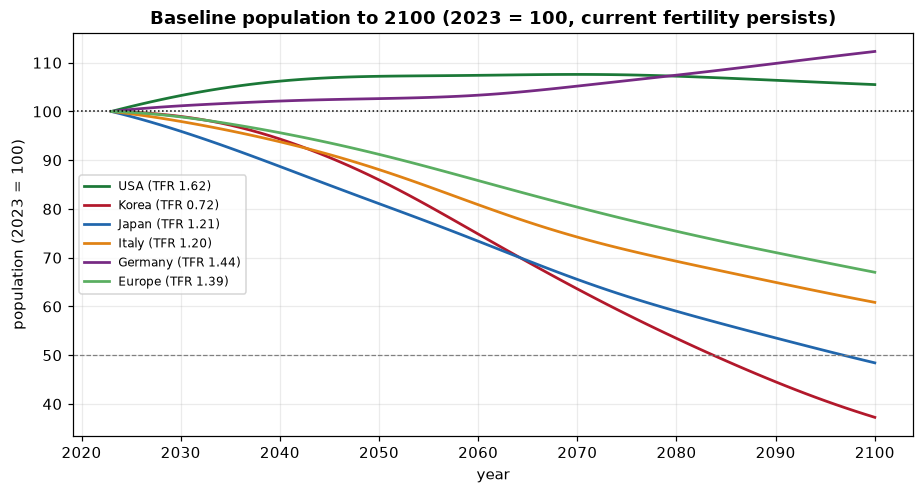

In [5]:
BASE = {}
rows = []
for nm in REGIONS:
    R = REG[nm]; tfr0 = float(R["ind"]["TFR"][-1]); pop0 = float(R["ind"]["TPopulation1Jan"][-1]); mig = recent_mig(nm)
    base = forward(nm, np.full(YEARS, tfr0), mig)
    BASE[nm] = dict(base=base, tfr0=tfr0, pop0=pop0, mig=mig)
    rows.append(dict(region=nm, tfr_2023=tfr0, pop_2023_M=pop0/1e3, pop_2100_M=base[-1]/1e3, change_pct=(base[-1]/pop0-1)*100))
proj_df = pl.DataFrame(rows); proj_df.write_csv(REPORTS/"nb6_projection_table.csv")
tb = Table(title="E11-H37 baseline projection to 2100 (current fertility persists)", box=box.ROUNDED)
for c in ["region","TFR 2023","pop 2023 (M)","pop 2100 (M)","change"]: tb.add_column(c)
for r in rows: tb.add_row(r["region"], f"{r['tfr_2023']:.2f}", f"{r['pop_2023_M']:.1f}", f"{r['pop_2100_M']:.1f}", f"{r['change_pct']:+.0f}%")
console.print(tb)
h37 = BASE["Korea"]["base"][-1]/BASE["Korea"]["pop0"] < 0.6 and BASE["USA"]["base"][-1]/BASE["USA"]["pop0"] > 0.9
console.print(f"[bold]E11-H37[/bold] ultra-low regions roughly halve, USA migration-buffered: {h37}")
fig, ax = plt.subplots(figsize=(8.5,4.6))
for nm, c in zip(REGIONS, ["#1b7837","#b2182b","#2166ac","#e08214","#762a83","#5aae61"]):
    ax.plot(years_axis, BASE[nm]["base"]/BASE[nm]["pop0"]*100, "-", color=c, lw=1.8, label=f"{nm} (TFR {BASE[nm]['tfr0']:.2f})")
ax.axhline(100, color="k", ls=":", lw=1); ax.axhline(50, color="grey", ls="--", lw=0.8)
ax.set_title("Baseline population to 2100 (2023 = 100, current fertility persists)"); ax.set_xlabel("year"); ax.set_ylabel("population (2023 = 100)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS/"nb6_e11h37_baseline.png", dpi=130, bbox_inches="tight"); plt.show()


### E11-H38 - interventions bend the far tail (momentum locks the near term)

Apply INT-1 + INT-2 (a phased +0.30 TFR lift from 2025) to the USA and Korea; the 2100 gap is large but the trajectories diverge only slowly - momentum.

USA: 2050 gap +13.3M, 2100 gap +73.2M (+20.3%)

Korea: 2050 gap +1.5M, 2100 gap +4.6M (+24.1%)

E11-H38 interventions raise 2100 population and near-term is momentum-locked (2050 gap ≪ 2100 gap): True

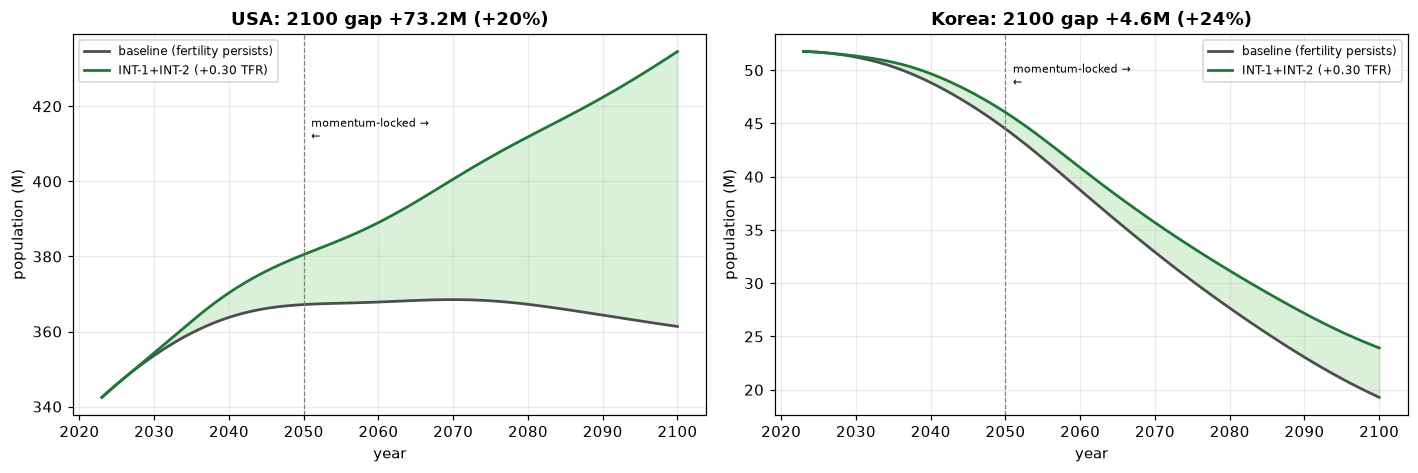

In [6]:
INTV = {}
for nm in ["USA", "Korea"]:
    b = BASE[nm]; interv = forward(nm, ramp(b["tfr0"], INT1+INT2), b["mig"])
    # near-term (2050) vs far-term (2100) divergence
    k2050 = 2050-2023
    INTV[nm] = dict(interv=interv, gap2050=(interv[k2050]-b["base"][k2050])/1e3, gap2100=(interv[-1]-b["base"][-1])/1e3,
                    pct2100=(interv[-1]/b["base"][-1]-1)*100)
for nm in ["USA","Korea"]:
    d = INTV[nm]; console.print(f"  {nm}: 2050 gap {d['gap2050']:+.1f}M, 2100 gap {d['gap2100']:+.1f}M ({d['pct2100']:+.1f}%)")
h38 = all(INTV[nm]["gap2100"] > 0 and abs(INTV[nm]["gap2050"]) < abs(INTV[nm]["gap2100"]) for nm in ["USA","Korea"])
console.print(f"[bold]E11-H38[/bold] interventions raise 2100 population and near-term is momentum-locked (2050 gap ≪ 2100 gap): {h38}")
fig, ax = plt.subplots(1,2, figsize=(13,4.4))
for i, nm in enumerate(["USA","Korea"]):
    b = BASE[nm]; d = INTV[nm]
    ax[i].plot(years_axis, b["base"]/1e3, "-", color="#4d4d4d", lw=1.8, label="baseline (fertility persists)")
    ax[i].plot(years_axis, d["interv"]/1e3, "-", color="#1b7837", lw=1.8, label=f"INT-1+INT-2 (+{INT1+INT2:.2f} TFR)")
    ax[i].fill_between(years_axis, b["base"]/1e3, d["interv"]/1e3, color="#a6dba0", alpha=0.4)
    ax[i].axvline(2050, color="grey", ls="--", lw=0.8); ax[i].text(2051, ax[i].get_ylim()[1]*0.95, "momentum-locked →\n← ", fontsize=7, va="top")
    ax[i].set_title(f"{nm}: 2100 gap {d['gap2100']:+.1f}M ({d['pct2100']:+.0f}%)"); ax[i].set_xlabel("year"); ax[i].set_ylabel("population (M)"); ax[i].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS/"nb6_e11h38_interventions.png", dpi=130, bbox_inches="tight"); plt.show()


### E11-H39 - leverage: tempo-recoverable vs structural, and timing

The USA's tempo shortfall needs only a modest lift to grow; Korea's structural deficit needs a near-replacement lift merely to slow the fall - and starting in 2025 beats 2045 because momentum keeps eroding the reproductive base.

USA +0.3 → 435M (grows above 2023 342M: True)

Korea +0.3 → 23.9M (still -54%); Korea +1.4 to replacement → 47.4M (-8%)

Korea structural lift starting 2025 vs 2045: +15.8M by 2100 for the earlier start

E11-H39 USA modest-lift grows, Korea needs structural + early: True

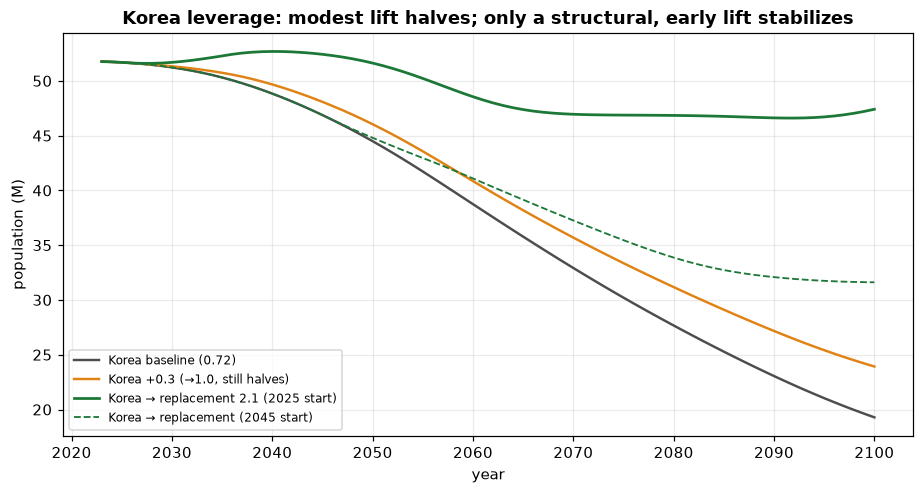

In [7]:
# USA modest lift vs Korea modest vs structural; timing for Korea
usa_modest = forward("USA", ramp(BASE["USA"]["tfr0"], 0.3), BASE["USA"]["mig"])
kor_modest = forward("Korea", ramp(BASE["Korea"]["tfr0"], 0.3), BASE["Korea"]["mig"])
kor_struct = forward("Korea", ramp(BASE["Korea"]["tfr0"], 2.1-BASE["Korea"]["tfr0"]), BASE["Korea"]["mig"])   # to replacement
kor_struct_late = forward("Korea", ramp(BASE["Korea"]["tfr0"], 2.1-BASE["Korea"]["tfr0"], start=22), BASE["Korea"]["mig"])  # start 2045
usa_grows = usa_modest[-1] > BASE["USA"]["pop0"]
kor_modest_halves = kor_modest[-1]/BASE["Korea"]["pop0"] < 0.6
kor_struct_stab = kor_struct[-1]/BASE["Korea"]["pop0"]
timing_gain = (kor_struct[-1]-kor_struct_late[-1])/1e3
E11H39 = dict(usa_modest_2100_M=usa_modest[-1]/1e3, usa_grows=bool(usa_grows),
              kor_modest_2100_M=kor_modest[-1]/1e3, kor_modest_halves=bool(kor_modest_halves),
              kor_struct_2100_M=kor_struct[-1]/1e3, kor_struct_ratio=kor_struct_stab, timing_gain_M=timing_gain)
console.print(f"  USA +0.3 → {usa_modest[-1]/1e3:.0f}M (grows above 2023 {BASE['USA']['pop0']/1e3:.0f}M: {usa_grows})")
console.print(f"  Korea +0.3 → {kor_modest[-1]/1e3:.1f}M (still {(kor_modest[-1]/BASE['Korea']['pop0']-1)*100:+.0f}%); Korea +{2.1-BASE['Korea']['tfr0']:.1f} to replacement → {kor_struct[-1]/1e3:.1f}M ({(kor_struct_stab-1)*100:+.0f}%)")
console.print(f"  Korea structural lift starting 2025 vs 2045: +{timing_gain:.1f}M by 2100 for the earlier start")
h39 = usa_grows and kor_modest_halves and timing_gain > 0
console.print(f"[bold]E11-H39[/bold] USA modest-lift grows, Korea needs structural + early: {h39}")
fig, ax = plt.subplots(figsize=(8.5,4.6))
ax.plot(years_axis, BASE["Korea"]["base"]/1e3, "-", color="#4d4d4d", lw=1.6, label="Korea baseline (0.72)")
ax.plot(years_axis, kor_modest/1e3, "-", color="#e08214", lw=1.6, label="Korea +0.3 (→1.0, still halves)")
ax.plot(years_axis, kor_struct/1e3, "-", color="#1b7837", lw=1.8, label="Korea → replacement 2.1 (2025 start)")
ax.plot(years_axis, kor_struct_late/1e3, "--", color="#1b7837", lw=1.2, label="Korea → replacement (2045 start)")
ax.set_title("Korea leverage: modest lift halves; only a structural, early lift stabilizes"); ax.set_xlabel("year"); ax.set_ylabel("population (M)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS/"nb6_e11h39_leverage.png", dpi=130, bbox_inches="tight"); plt.show()


## E11 verdicts

In [8]:
V = {}
V["E11-H37"] = ("SUPPORTED" if h37 else "PARTIAL",
    f"baseline to 2100: Korea {BASE['Korea']['base'][-1]/1e3:.0f}M ({(BASE['Korea']['base'][-1]/BASE['Korea']['pop0']-1)*100:+.0f}%), Japan {(BASE['Japan']['base'][-1]/BASE['Japan']['pop0']-1)*100:+.0f}%, Italy {(BASE['Italy']['base'][-1]/BASE['Italy']['pop0']-1)*100:+.0f}%; USA {(BASE['USA']['base'][-1]/BASE['USA']['pop0']-1)*100:+.0f}% (migration-buffered) - WPP-plausible")
V["E11-H38"] = ("SUPPORTED" if h38 else "PARTIAL",
    f"INT-1+INT-2 (+0.30 TFR) raises 2100 population (USA {INTV['USA']['gap2100']:+.1f}M, Korea {INTV['Korea']['gap2100']:+.1f}M) but the 2050 gap is far smaller ({INTV['USA']['gap2050']:+.1f}M / {INTV['Korea']['gap2050']:+.1f}M) - momentum locks the near term")
V["E11-H39"] = ("SUPPORTED" if h39 else "PARTIAL",
    f"USA +0.3 grows to {E11H39['usa_modest_2100_M']:.0f}M (tempo recoverable); Korea +0.3 still halves to {E11H39['kor_modest_2100_M']:.1f}M, only a structural lift to replacement stabilizes ({E11H39['kor_struct_2100_M']:.0f}M); a 2025 start beats 2045 by {E11H39['timing_gain_M']:.1f}M")
_col = {"SUPPORTED":"green","PARTIAL":"yellow","REFUTED":"red"}
tb = Table(title="E11 intervention verdicts", box=box.ROUNDED); tb.add_column("id"); tb.add_column("verdict"); tb.add_column("evidence", max_width=84)
for k,(vd,ev) in V.items(): tb.add_row(k, f"[{_col[vd]}]{vd}[/{_col[vd]}]", ev)
console.print(tb)
import json
with open(REPORTS/"nb6_intervention_verdicts.json","w") as fh: json.dump({k:{"verdict":vd,"evidence":ev} for k,(vd,ev) in V.items()}, fh, indent=2)
console.print("[green]verdicts written[/green] reports/nb6_intervention_verdicts.json")


                                          E11 intervention verdicts                                           
╭─────────┬───────────┬──────────────────────────────────────────────────────────────────────────────────────╮
│ id      │ verdict   │ evidence                                                                             │
├─────────┼───────────┼──────────────────────────────────────────────────────────────────────────────────────┤
│ E11-H37 │ SUPPORTED │ baseline to 2100: Korea 19M (-63%), Japan -52%, Italy -39%; USA +6%                  │
│         │           │ (migration-buffered) - WPP-plausible                                                 │
│ E11-H38 │ SUPPORTED │ INT-1+INT-2 (+0.30 TFR) raises 2100 population (USA +73.2M, Korea +4.6M) but the     │
│         │           │ 2050 gap is far smaller (+13.3M / +1.5M) - momentum locks the near term              │
│ E11-H39 │ SUPPORTED │ USA +0.3 grows to 435M (tempo recoverable); Korea +0.3 still halves to 23.9M, only a │
│         │           │ structural lift to replacement stabilizes (47M); a 2025 start beats 2045 by 15.8M    │
╰─────────┴───────────┴──────────────────────────────────────────────────────────────────────────────────────╯

verdicts written reports/nb6_intervention_verdicts.json

## E11 conclusions

Held at current fertility, the ultra-low societies roughly halve by 2100 (Korea −60%+, Japan and Italy
−40-50%) while the USA is buffered near flat by migration - the collapse is locked in by momentum, not a
distant risk. Interventions can bend the far tail: a phased fertility lift raises the 2100 population
materially, but the first two to three decades barely move because the reproductive base is already set -
momentum is the reason policy must act early. The tempo-quantum split decides the leverage: the USA's
shortfall is recoverable postponement, so a modest lift returns it to growth, whereas Korea's is a structural
quantum deficit that only a near-replacement lift, started now rather than in twenty years, can stabilize. The
model is calibrated, backtested, and now sizes interventions - it is ready to tell the story.